In [3]:
import sys
sys.path.append('..')

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from src.models.covariance import COV_DIR
from src.models.covariance import load_covariance, mp_pdf, mp_upper_edge, fit_sigma2, cov2corr

from src.models.covariance import (
    load_covariance, mp_pdf, mp_upper_edge, fit_sigma2, cov2corr, COV_DIR
)

plt.rcParams.update({
    'figure.figsize': (12, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
})

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str) -> None:
    plt.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")

dates = sorted([p.stem for p in COV_DIR.glob('*.parquet')])
print(f'{len(dates)} matrices  |  {dates[0]} to {dates[-1]}')

207 matrices  |  2007-10-31 to 2024-12-31


The empirical eigenvalue distribution of the **raw** correlation matrix should match the MP density in the bulk. Signal eigenvalues appear as isolated spikes above $\lambda_+$.

After cleaning, the bulk collapses to a constant (the noise mean) and only the signal eigenvalues remain.

$$f(\lambda) = \frac{1/q}{2\pi\sigma^2\lambda}\sqrt{(\lambda_+ - \lambda)(\lambda - \lambda_-)} \qquad \lambda_\pm = \sigma^2(1 \pm \sqrt{q})^2$$

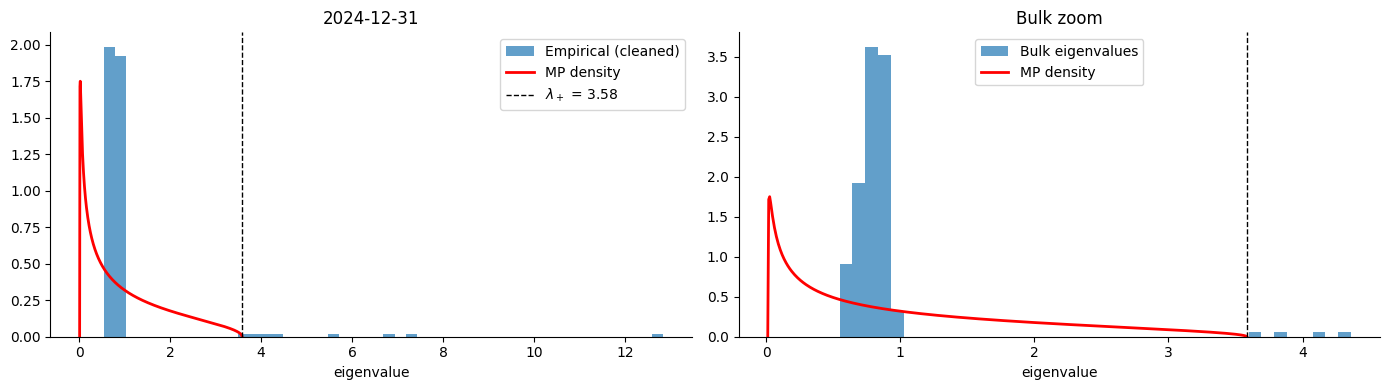

sigma2=1.0000, lambda+=3.5838
Signal eigenvalues: 8 / 201


In [4]:
Sigma, symbols = load_covariance(dates[-1])
N = len(symbols)
q = N / 252
C_clean, std = cov2corr(Sigma)
eVal_clean   = np.linalg.eigvalsh(C_clean)

sigma2    = fit_sigma2(eVal_clean, q)
threshold = mp_upper_edge(q, sigma2)
eVal_mp, pdf_mp = mp_pdf(sigma2, q, pts=500)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(eVal_clean, bins=50, density=True, alpha=0.7, label='Empirical (cleaned)')
axes[0].plot(eVal_mp, pdf_mp, 'r-', linewidth=2, label='MP density')
axes[0].axvline(threshold, color='k', linestyle='--', linewidth=1, label=f'$\\lambda_+$ = {threshold:.2f}')
axes[0].set_title(f'{dates[-1]}')
axes[0].set_xlabel('eigenvalue')
axes[0].legend()

bulk_mask = eVal_clean <= threshold * 1.5
axes[1].hist(eVal_clean[bulk_mask], bins=40, density=True, alpha=0.7, label='Bulk eigenvalues')
axes[1].plot(eVal_mp, pdf_mp, 'r-', linewidth=2, label='MP density')
axes[1].axvline(threshold, color='k', linestyle='--', linewidth=1)
axes[1].set_title('Bulk zoom')
axes[1].set_xlabel('eigenvalue')
axes[1].legend()

plt.tight_layout()
save_fig("02_covariance_mp_spectrum.png")
plt.show()

print(f'sigma2={sigma2:.4f}, lambda+={threshold:.4f}')
print(f'Signal eigenvalues: {int((eVal_clean > threshold).sum())} / {N}')

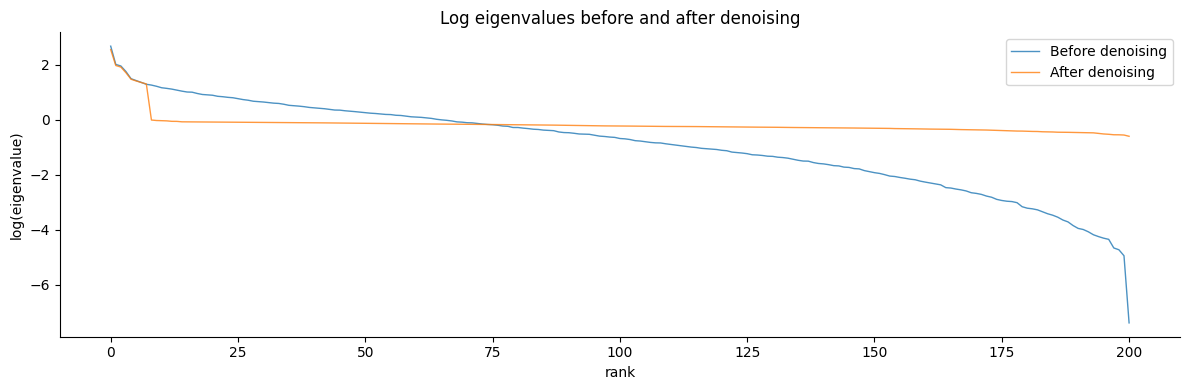

In [5]:
from datetime import date
from src.signals.residuals import load_residuals

# MLAM Fig 2.3: log spectrum before/after denoising (last date)
R = load_residuals()
last_date = date.fromisoformat(dates[-1])

window = (
    R.filter(pl.col("symbol").is_in(symbols))
     .filter(pl.col("date") <= last_date)
     .sort("date")
     .group_by("symbol")
     .tail(252)
)

wide = (
    window
    .pivot(index="date", on="symbol", values="residual")
    .sort("date")
)

coverage = {c: wide[c].is_not_null().sum() for c in symbols}
selected = sorted(symbols, key=lambda c: coverage[c], reverse=True)[:201]
E = wide.select(selected).fill_null(0.0).to_numpy()

C_raw, _ = cov2corr(np.cov(E, rowvar=False))
e_raw = np.sort(np.linalg.eigvalsh(C_raw))[::-1]
e_clean = np.sort(np.linalg.eigvalsh(cov2corr(Sigma)[0]))[::-1]

eps = 1e-12
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(np.log(e_raw + eps), lw=1.0, alpha=0.8, label="Before denoising")
ax.plot(np.log(e_clean + eps), lw=1.0, alpha=0.8, label="After denoising")
ax.set_title("Log eigenvalues before and after denoising")
ax.set_xlabel("rank")
ax.set_ylabel("log(eigenvalue)")
ax.legend()
plt.tight_layout()
save_fig("02_covariance_log_spectrum.png")
plt.show()

$\kappa = \lambda_{max} / \lambda_{min}$. A large condition number means the matrix is nearly singular so we have to be careful about inverting it.

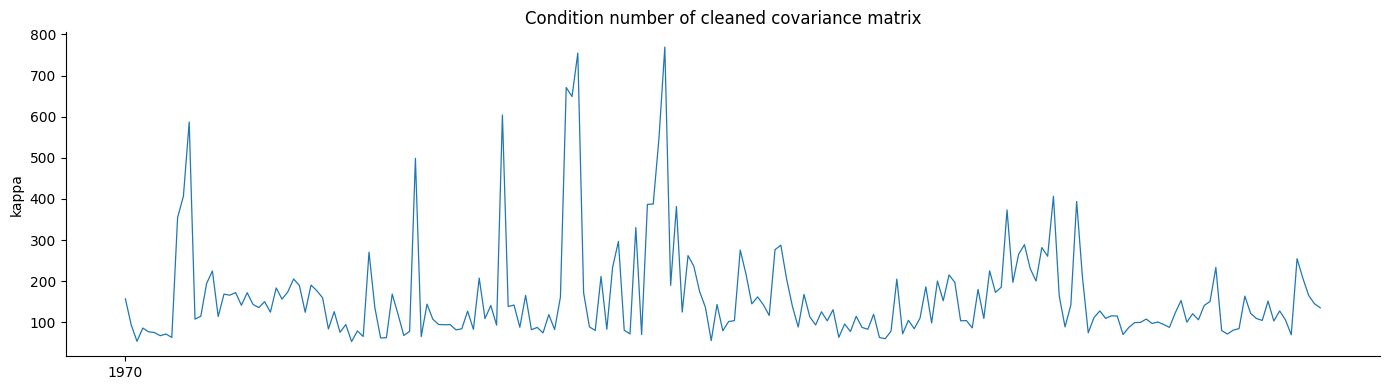

Median kappa : 124.8
Max kappa    : 769.3  (2015-07-31)


In [9]:
from datetime import datetime

if len(dates) == 0:
    dates = [datetime.strptime(d, "%Y-%m-%d") for d in dates]

cond_clean = []
traces = []

for d in dates:
    Sigma, _ = load_covariance(d)
    eVals = np.linalg.eigvalsh(Sigma)
    cond_clean.append(eVals.max() / eVals.min())
    traces.append(np.trace(Sigma))

cond_clean = np.array(cond_clean)
traces = np.array(traces)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates, cond_clean, linewidth=0.9)
ax.set_title("Condition number of cleaned covariance matrix")
ax.set_ylabel("kappa")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
save_fig("02_covariance_condition_number.png")
plt.show()

print(f"Median kappa : {np.median(cond_clean):.1f}")
print(f"Max kappa    : {np.max(cond_clean):.1f}  ({dates[np.argmax(cond_clean)]})")

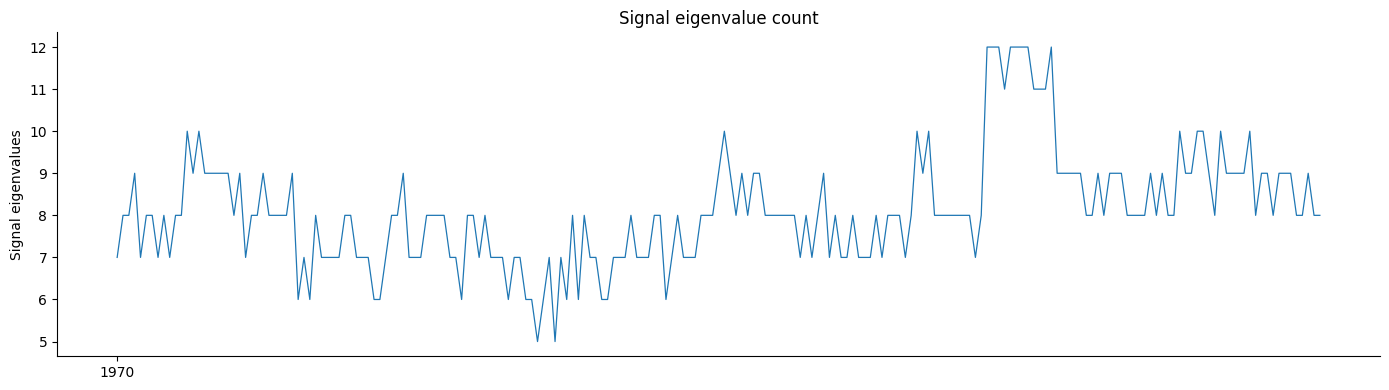

Mean  : 8.1
Max   : 12  (2020-03-31)
Min   : 5


In [10]:
signal_counts = []

for d in dates:
    Sigma, _ = load_covariance(d)
    N = Sigma.shape[0]
    q = N / 252
    C, _ = cov2corr(Sigma)
    eVals = np.linalg.eigvalsh(C)
    sigma2 = fit_sigma2(eVals, q)
    threshold = mp_upper_edge(q, sigma2)
    signal_counts.append(int((eVals > threshold).sum()))

signal_counts = np.array(signal_counts)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates, signal_counts, linewidth=0.9)
ax.set_title("Signal eigenvalue count")
ax.set_ylabel("Signal eigenvalues")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
save_fig("02_covariance_signal_eigs.png")
plt.show()

print(f"Mean  : {signal_counts.mean():.1f}")
print(f"Max   : {signal_counts.max()}  ({dates[np.argmax(signal_counts)]})")
print(f"Min   : {signal_counts.min()}")

$\text{tr}(\tilde{\Sigma}) \approx \text{tr}(\hat{\Sigma})$

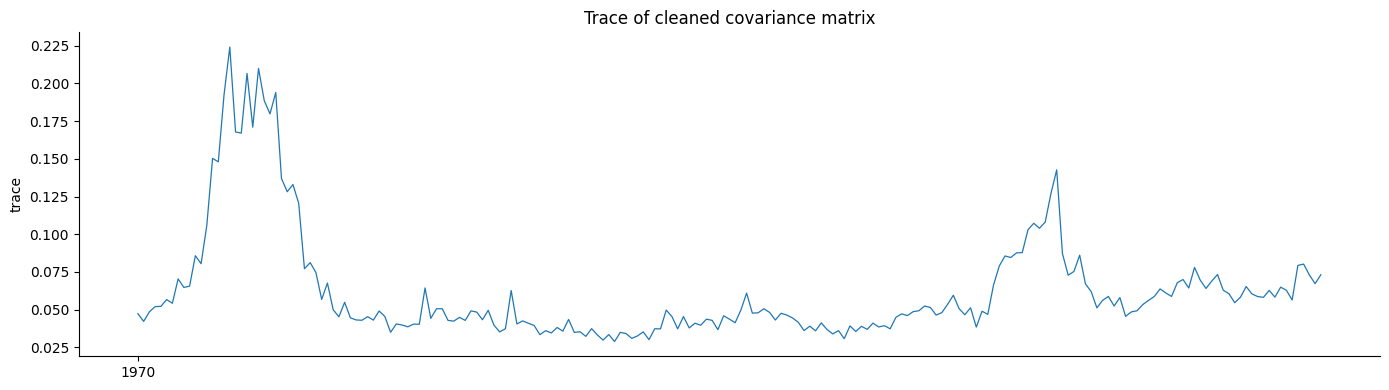

Mean trace            : 0.06229
Implied annualized vol: 27.9%


In [12]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates, traces, linewidth=0.9)
ax.set_title("Trace of cleaned covariance matrix")
ax.set_ylabel("trace")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
save_fig("02_covariance_trace.png")
plt.show()

avg_daily_var = np.mean(traces) / 201
avg_ann_vol = np.sqrt(avg_daily_var * 252)
print(f"Mean trace            : {np.mean(traces):.5f}")
print(f"Implied annualized vol: {avg_ann_vol:.1%}")

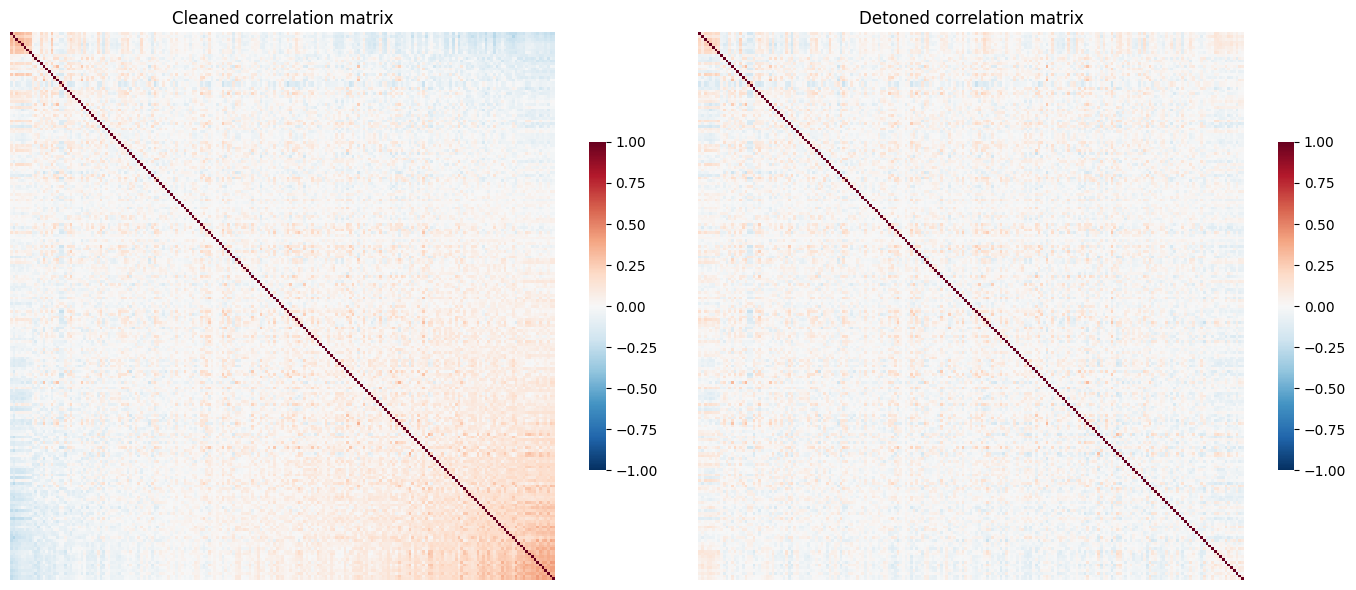

In [13]:
from src.models.covariance import detone

Sigma, symbols = load_covariance(dates[-1])
C, _ = cov2corr(Sigma)
C_det = detone(C, n_factors=1)

_, eVec = np.linalg.eigh(C)
sort_idx = np.argsort(eVec[:, -1])

C_sorted = C[np.ix_(sort_idx, sort_idx)]
C_det_sorted = C_det[np.ix_(sort_idx, sort_idx)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(C_sorted, ax=axes[0], cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, xticklabels=False, yticklabels=False,
            cbar_kws={"shrink": 0.6})
axes[0].set_title("Cleaned correlation matrix")

sns.heatmap(C_det_sorted, ax=axes[1], cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, xticklabels=False, yticklabels=False,
            cbar_kws={"shrink": 0.6})
axes[1].set_title("Detoned correlation matrix")

plt.tight_layout()
save_fig("02_covariance_heatmaps.png")
plt.show()

All matrices must have strictly positive eigenvalues for the portfolio optimizer. One failed matrix crashes the QP.

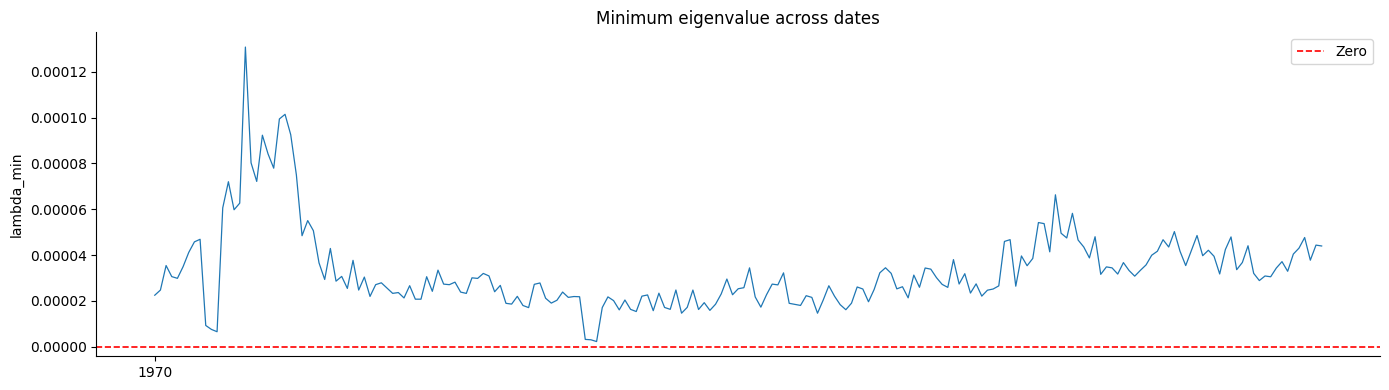

In [15]:
failures = []
min_eigs = []

for d in dates:
    Sigma, _ = load_covariance(d)
    eVals = np.linalg.eigvalsh(Sigma)
    min_eigs.append(eVals.min())
    if eVals.min() <= 0:
        failures.append(d)

min_eigs = np.array(min_eigs)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates, min_eigs, linewidth=0.9)
ax.axhline(0, color="red", linewidth=1.2, linestyle="--", label="Zero")
ax.set_title("Minimum eigenvalue across dates")
ax.set_ylabel("lambda_min")
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
save_fig("02_covariance_min_eigenvalue.png")
plt.show()
